In [1]:
# 1. get some cacao observation, select those that are likely agroforest

In [2]:
import geopandas as gpd
import pandas as pd

gdf = gpd.read_file("/Users/szelie/data/unu/agroforestry_systems/dominican_republic.geojson")
gdf_cacao = gdf[gdf.key_species=="Theobroma cacao"]

In [3]:
gdf_cacao

,uid,key_species,associated_species,canopy_height,forest_cover,land_use,land_use_class,has_associates,system_type,geometry
1,81,Theobroma cacao,,6.0,0.0,10.0,Tree cover,False,Mixed or unclear,POINT (-71.22754 19.60170)
6,720,Theobroma cacao,,NaN,25.0,50.0,Built-up,False,Unknown,POINT (-69.25611 18.75944)
7,729,Theobroma cacao,,10.0,46.0,50.0,Built-up,False,Mixed or unclear,POINT (-69.92183 19.45879)
8,782,Theobroma cacao,"Artocarpus altilis, Mangifera indica",17.0,43.0,10.0,Tree cover,True,Mixed or unclear,POINT (-69.58716 18.81537)
9,830,Theobroma cacao,,16.0,41.0,10.0,Tree cover,False,Mixed or unclear,POINT (-69.33841 18.88577)
...,...,...,...,...,...,...,...,...,...,...
129,580946,Theobroma cacao,Lantana camara,14.0,72.0,10.0,Tree cover,True,Likely agroforestry,POINT (-68.67541 18.69891)
130,583163,Theobroma cacao,"Adiantum tenerum, Calophyllum brasiliense, Cyc...",19.0,96.0,10.0,Tree cover,True,Likely agroforestry,POINT (-70.81923 19.73540)
131,584677,Theobroma cacao,"Cyclopeltis semicordata, Guarea guidonia, Pipe...",25.0,92.0,10.0,Tree cover,True,Likely agroforestry,POINT (-69.46615 19.06785)
133,584990,Theobroma cacao,,14.0,35.0,30.0,Grassland,False,Mixed or unclear,POINT (-69.48076 18.67022)


# 2.  Algorithm: Simulate Agroforestry Plot

This function simulates the structure of an agroforestry system based on available observational data (e.g. forest cover, canopy height, associated species) and plausible assumptions for missing information.

#### Steps:

1. **Input Data Extraction**
   - Extract `geometry`, `forest_cover`, `canopy_height`, and any `associated_species` from the input row.

2. **Agroforestry Classification**
   - Classify the plot as a likely agroforestry system if:
     - Forest cover ≥ 20%, or
     - Canopy height ≥ 5 m, or
     - At least one known shade tree is listed in `associated_species`.

   - If not, return a minimal GeoDataFrame with `"system_type": "Non-agroforestry"`.

3. **Plot Size Simulation**
   - If not given, sample a plot size (in m²) from predefined ranges using weighted probabilities to reflect common plot sizes.

4. **Cacao Density**
   - If not given, randomly select a cacao tree density (800–1400 trees/ha).
   - Convert this to a number of cacao trees based on the simulated plot size.

5. **Shade Tree Species Composition**
   - If a user-defined species dictionary is provided, use it directly.
   - Otherwise:
     - Extract known shade trees from `associated_species`.
     - Decide on the total number of shade trees to simulate based on forest cover (max 50).
     - Adjust species selection based on canopy height:
       - Exclude very tall trees if canopy height is low.
       - Favour taller trees if canopy height is high.
     - Fill in remaining trees by sampling from a fallback pool with probabilities.
     - Optionally, restrict the number of unique species (if `n_shade_species` is defined).

6. **Assign Roles**
   - Assign each species a role (e.g. “shade + food”, “market”) based on a lookup table.

7. **Return Output**
   - Return a GeoDataFrame with:
     - Tree species and counts
     - Roles
     - Number of cacao trees
     - Plot size, density, forest cover, canopy height
     - Land use and system classification
     - Location geometry

This framework enables integration of observed and simulated data for spatial agroforestry modelling and can be extended with shade simulations or climate suitability assessments.


In [4]:
default_shade_species = [
    {"name": "Musa sp.", "prob": 0.4, "role": "shade + food"},
    {"name": "Persea americana", "prob": 0.2, "role": "shade + market"},
    {"name": "Citrus sinensis", "prob": 0.1, "role": "shade + food"},
    {"name": "Pouteria sapota", "prob": 0.05, "role": "food"},
    {"name": "Artocarpus altilis", "prob": 0.05, "role": "food + market"},
    {"name": "Hura crepitans", "prob": 0.05, "role": "large shade"},
    {"name": "Spathodea campanulata", "prob": 0.05, "role": "ornamental"},
    {"name": "Clusia rosea", "prob": 0.05, "role": "shade"},
    {"name": "Ficus spp.", "prob": 0.05, "role": "parasitic"},
]

known_shade_trees = {
    "Mangifera indica", "Artocarpus altilis", "Persea americana",
    "Hura crepitans", "Guarea guidonia", "Spathodea campanulata",
    "Roystonea borinquena", "Ficus elastica", "Ceiba pentandra",
    "Clusia rosea", "Terminalia catappa", "Simarouba glauca",
    "Pouteria sapota", "Annona muricata"
}

# --- Species height dictionary ---
species_heights = {
    "Musa sp.": (3, 6),
    "Persea americana": (8, 15),
    "Citrus sinensis": (4, 8),
    "Pouteria sapota": (12, 18),
    "Artocarpus altilis": (10, 20),
    "Hura crepitans": (20, 30),
    "Spathodea campanulata": (10, 15),
    "Clusia rosea": (10, 15),
    "Ficus spp.": (20, 30),
    "Mangifera indica": (10, 20),
    "Guarea guidonia": (15, 25),
    "Roystonea borinquena": (20, 30),
    "Ficus elastica": (15, 25),
    "Ceiba pentandra": (25, 40),
    "Terminalia catappa": (10, 18),
    "Simarouba glauca": (10, 20),
    "Annona muricata": (4, 8),
    "Theobroma cacao": (4, 8),
}

plot_size_distribution = [
    (300, 800),
    (800, 1200),
    (1200, 1800),
    (1800, 2500),
]
plot_size_weights = [0.3, 0.4, 0.2, 0.1]

cacao_density_distribution = (800, 1400)


def estimate_shade_per_tree(species):
    min_h, max_h = species_heights.get(species, (8, 12))
    avg_h = (min_h + max_h) / 2
    shade_radius = 0.4 * avg_h
    return np.pi * (shade_radius ** 2)


def simulate_agroforestry_plot(row,
                                plot_size_m2=None,
                                cacao_density_per_ha=None,
                                n_shade_trees=None,
                                n_shade_species=None,
                                species_dict=None):
    geometry = wkt.loads(str(row.geometry))
    forest_cover = row.get("forest_cover", 0)
    canopy_height = row.get("canopy_height", None)
    land_use_class = row.get("land_use_class", "Unknown")
    raw_associates = row.get("associated_species", "")
    real_associates = set(map(str.strip, raw_associates.split(","))) if raw_associates else set()

    # Simulate cacao plot size and density
    if plot_size_m2 is None:
        r = random.choices(plot_size_distribution, weights=plot_size_weights)[0]
        plot_size_m2 = random.randint(r[0], r[1])
    if cacao_density_per_ha is None:
        cacao_density_per_ha = random.randint(*cacao_density_distribution)
    n_cacao = int((plot_size_m2 / 10_000) * cacao_density_per_ha)

    # Skip plots that are not agroforestry
    is_agroforestry = (
        (forest_cover is not None and forest_cover >= 20) and
        (land_use_class not in ["Built-up", "Bare", "Water"])
    )
    if not is_agroforestry:
        return None

    # Use provided species dictionary or simulate
    if species_dict is not None and isinstance(species_dict, dict):
        counts = species_dict
        species_source = "user"
    else:
        real_shade_trees = [s for s in real_associates if s in known_shade_trees and s != "Theobroma cacao"]

        if n_shade_trees is None:
            target_shade_area = plot_size_m2 * (forest_cover / 100)
            valid_shades = [estimate_shade_per_tree(s["name"]) for s in default_shade_species]
            valid_shades = [s for s in valid_shades if not np.isnan(s)]
            if not valid_shades:
                return None
            avg_shade_per_tree = np.mean(valid_shades)
            n_shade_trees = int(np.ceil(target_shade_area / avg_shade_per_tree))
            n_shade_trees = max(3, min(n_shade_trees, 50))

        available_species = default_shade_species
        if canopy_height is not None:
            if canopy_height < 10:
                available_species = [s for s in available_species if "Ficus" not in s["name"] and "Hura" not in s["name"]]
            elif canopy_height > 20:
                available_species = [s for s in available_species if "Hura" in s["name"] or "Ficus" in s["name"]]

        n_existing = len(real_shade_trees)
        n_needed = max(0, n_shade_trees - n_existing)

        if n_shade_species is not None:
            unique_pool = list(set(s["name"] for s in available_species) - set(real_shade_trees))
            extra_species = random.sample(unique_pool, min(n_shade_species - n_existing, len(unique_pool)))
            full_pool = real_shade_trees + extra_species
            species_list = random.choices(full_pool, k=n_shade_trees)
        else:
            species_list = real_shade_trees + random.choices(
                [s["name"] for s in available_species],
                weights=[s["prob"] for s in available_species],
                k=n_needed
            )

        counts = {}
        for s in species_list:
            counts[s] = counts.get(s, 0) + 1
        species_source = "observed + simulated" if real_shade_trees else "simulated"

    # Skip plots with no valid shade trees
    if not counts:
        return None

    role_lookup = {s["name"]: s["role"] for s in default_shade_species}

    gdf = gpd.GeoDataFrame(
        {
            "species": list(counts.keys()),
            "n_trees": list(counts.values()),
            "role": [role_lookup.get(s, "shade") for s in counts.keys()],
            "cacao_trees": [n_cacao] * len(counts),
            "plot_size_m2": [plot_size_m2] * len(counts),
            "cacao_density_per_ha": [cacao_density_per_ha] * len(counts),
            "forest_cover": [forest_cover] * len(counts),
            "canopy_height": [canopy_height] * len(counts),
            "land_use_class": [land_use_class] * len(counts),
            "system_type": ["Agroforestry"] * len(counts),
            "source": [species_source] * len(counts)
        },
        geometry=[geometry] * len(counts),
        crs="EPSG:4326"
    )

    return gdf


In [5]:
gdf.iloc[6]

uid                                            720
key_species                        Theobroma cacao
associated_species                                
canopy_height                                  NaN
forest_cover                                  25.0
land_use                                      50.0
land_use_class                            Built-up
has_associates                               False
system_type                                Unknown
geometry              POINT (-69.256113 18.759442)
Name: 6, dtype: object

In [6]:
gdf.iloc[8] 

uid                                                    782
key_species                                Theobroma cacao
associated_species    Artocarpus altilis, Mangifera indica
canopy_height                                         17.0
forest_cover                                          43.0
land_use                                              10.0
land_use_class                                  Tree cover
has_associates                                        True
system_type                               Mixed or unclear
geometry                      POINT (-69.587161 18.815366)
Name: 8, dtype: object

In [7]:
from shapely import wkt
import random
import numpy as np



simulated_agroforest = simulate_agroforestry_plot(gdf.iloc[8])
simulated_agroforest

,species,n_trees,role,cacao_trees,plot_size_m2,cacao_density_per_ha,forest_cover,canopy_height,land_use_class,system_type,source,geometry
0,Artocarpus altilis,1,food + market,169,1796,943,43.0,17.0,Tree cover,Agroforestry,observed + simulated,POINT (-69.58716 18.81537)
1,Mangifera indica,1,shade,169,1796,943,43.0,17.0,Tree cover,Agroforestry,observed + simulated,POINT (-69.58716 18.81537)
2,Clusia rosea,1,shade,169,1796,943,43.0,17.0,Tree cover,Agroforestry,observed + simulated,POINT (-69.58716 18.81537)
3,Musa sp.,2,shade + food,169,1796,943,43.0,17.0,Tree cover,Agroforestry,observed + simulated,POINT (-69.58716 18.81537)
4,Citrus sinensis,1,shade + food,169,1796,943,43.0,17.0,Tree cover,Agroforestry,observed + simulated,POINT (-69.58716 18.81537)
5,Spathodea campanulata,1,ornamental,169,1796,943,43.0,17.0,Tree cover,Agroforestry,observed + simulated,POINT (-69.58716 18.81537)


In [8]:

# Example: specify both number of species and trees
simulate_agroforestry_plot(gdf.iloc[8], n_shade_species=4, n_shade_trees=15)


,species,n_trees,role,cacao_trees,plot_size_m2,cacao_density_per_ha,forest_cover,canopy_height,land_use_class,system_type,source,geometry
0,Musa sp.,2,shade + food,60,741,811,43.0,17.0,Tree cover,Agroforestry,observed + simulated,POINT (-69.58716 18.81537)
1,Artocarpus altilis,3,food + market,60,741,811,43.0,17.0,Tree cover,Agroforestry,observed + simulated,POINT (-69.58716 18.81537)
2,Clusia rosea,5,shade,60,741,811,43.0,17.0,Tree cover,Agroforestry,observed + simulated,POINT (-69.58716 18.81537)
3,Mangifera indica,5,shade,60,741,811,43.0,17.0,Tree cover,Agroforestry,observed + simulated,POINT (-69.58716 18.81537)


In [9]:
# 3. fetch fao info for temp/precip requirements for that agroforestry system

In [10]:
# Fully simulated
simulate_agroforestry_plot(gdf.iloc[8])

# Simulate with user-defined species count and tree count
simulate_agroforestry_plot(gdf.iloc[8], n_shade_species=4, n_shade_trees=12)

# Precise field observation
simulated_agroforest = simulate_agroforestry_plot(gdf.iloc[8], species_dict={
    "Mangifera indica": 5,
    "Artocarpus altilis": 3,
    "Persea americana": 4
})


In [11]:
simulated_agroforest

,species,n_trees,role,cacao_trees,plot_size_m2,cacao_density_per_ha,forest_cover,canopy_height,land_use_class,system_type,source,geometry
0,Mangifera indica,5,shade,307,2493,1234,43.0,17.0,Tree cover,Agroforestry,user,POINT (-69.58716 18.81537)
1,Artocarpus altilis,3,food + market,307,2493,1234,43.0,17.0,Tree cover,Agroforestry,user,POINT (-69.58716 18.81537)
2,Persea americana,4,shade + market,307,2493,1234,43.0,17.0,Tree cover,Agroforestry,user,POINT (-69.58716 18.81537)


In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random
from scipy.ndimage import gaussian_filter



# --- Shade functions ---

def assign_shade_value_column(gdf):
    gdf = gdf.copy()
    gdf["raw_shade_area"] = gdf.apply(
        lambda row: row.n_trees * estimate_shade_per_tree(row.species)
        if pd.notnull(row.species) else 0,
        axis=1
    )
    return gdf

def normalize_shade_to_forest_cover(gdf):
    gdf = assign_shade_value_column(gdf)
    gdfs = []
    for geom, group in gdf.groupby("geometry"):
        # Add cacao contribution
        if not (group["species"] == "Theobroma cacao").any():
            cacao_area = estimate_shade_per_tree("Theobroma cacao") * group["cacao_trees"].iloc[0]
            cacao_row = group.iloc[0].copy()
            cacao_row["species"] = "Theobroma cacao"
            cacao_row["n_trees"] = group["cacao_trees"].iloc[0]
            cacao_row["raw_shade_area"] = cacao_area
            group = pd.concat([group, pd.DataFrame([cacao_row])], ignore_index=True)

        total_raw = group["raw_shade_area"].sum()
        target_cover_area = group.plot_size_m2.iloc[0] * (group.forest_cover.iloc[0] / 100)
        if total_raw > 0:
            group["shade_value"] = group["raw_shade_area"] * (target_cover_area / total_raw)
        else:
            group["shade_value"] = 0
        gdfs.append(group)
    return pd.concat(gdfs).reset_index(drop=True)

# --- Simulation functions ---
def get_tree_height(species):
    return random.uniform(*species_heights.get(species, (8, 12)))

def simulate_tree_layout_with_height(gdf, plot_width=30, plot_height=30):
    rows = []
    for _, row in gdf.iterrows():
        for _ in range(int(row.n_trees)):
            x = random.uniform(0, plot_width)
            y = random.uniform(0, plot_height)
            height = get_tree_height(row.species)
            rows.append({"species": row.species, "x": x, "y": y, "height": height})
    return pd.DataFrame(rows)

def simulate_cacao_layout_with_height(n_cacao, plot_width=30, plot_height=30):
    return pd.DataFrame({
        "species": ["Theobroma cacao"] * n_cacao,
        "x": [random.uniform(0, plot_width) for _ in range(n_cacao)],
        "y": [random.uniform(0, plot_height) for _ in range(n_cacao)],
        "height": [get_tree_height("Theobroma cacao") for _ in range(n_cacao)]
    })

def generate_canopy_cover_map(tree_df, plot_size=30, resolution=0.5):
    grid_size = int(plot_size / resolution)
    pixel_area = resolution * resolution
    shade_map = np.zeros((grid_size, grid_size))

    for _, row in tree_df.iterrows():
        cx, cy = row.x, row.y
        radius = 0.4 * row.height

        for i in range(grid_size):
            for j in range(grid_size):
                x, y = i * resolution + (resolution / 2), j * resolution + (resolution / 2)
                dist = np.sqrt((x - cx)**2 + (y - cy)**2)
                if dist <= radius:
                    shade_map[j, i] += 1

    shade_map = np.clip(shade_map, 0, 1)
    shade_map = gaussian_filter(shade_map, sigma=1)
    return shade_map

def plot_canopy_cover_map(shade_map, title="Simulated % Canopy Cover"):
    plt.figure(figsize=(6, 6))
    im = plt.imshow(shade_map, cmap="Greens", origin="lower", extent=[0, 30, 0, 30], vmin=0, vmax=1)
    cbar = plt.colorbar(im)
    cbar.set_label("Canopy Cover (%)")
    cbar.set_ticks([0, 0.25, 0.5, 0.75, 1])
    cbar.set_ticklabels(["0%", "25%", "50%", "75%", "100%"])
    plt.title(title)
    plt.xlabel("x (m)")
    plt.ylabel("y (m)")
    plt.gca().set_aspect("equal")
    plt.tight_layout()
    plt.show()

def plot_agroforest_with_height_from_df(tree_df, cacao_df, plot_width=30, plot_height=30):
    combined_df = pd.concat([tree_df, cacao_df], ignore_index=True)
    combined_df["size"] = combined_df["height"] * 4
    plt.figure(figsize=(6, 6))
    ax = sns.scatterplot(
        data=combined_df,
        x="x", y="y",
        hue="species",
        size="size",
        sizes=(20, 300),
        alpha=0.7,
        palette="tab10",
        legend="brief"
    )
    plt.title("Agroforestry Plot with Tree Height and Density")
    plt.xlabel("x (m)")
    plt.ylabel("y (m)")
    plt.xlim(0, plot_width)
    plt.ylim(0, plot_height)
    plt.gca().set_aspect("equal")
    plt.tight_layout()
    handles, labels = ax.get_legend_handles_labels()
    species_labels = list(set(combined_df["species"]))
    filtered = [(h, l) for h, l in zip(handles, labels) if l in species_labels]
    if filtered:
        h, l = zip(*filtered)
        plt.legend(h, l, bbox_to_anchor=(1.05, 1), loc='upper left', title="Species")
    else:
        plt.legend([], [], frameon=False)
    plt.show()


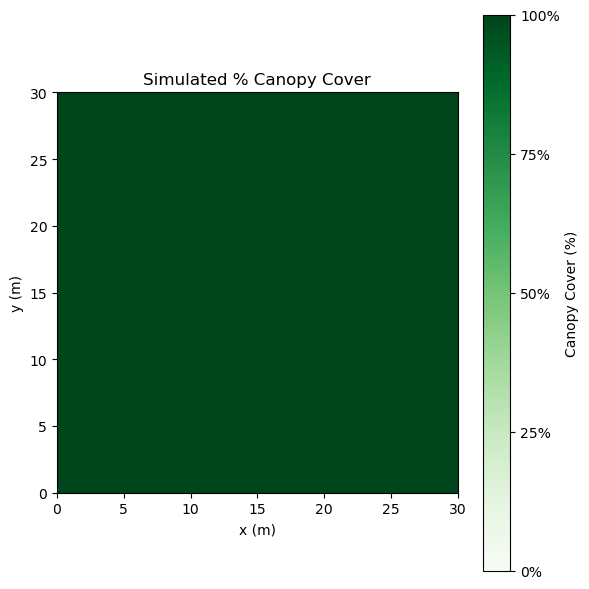

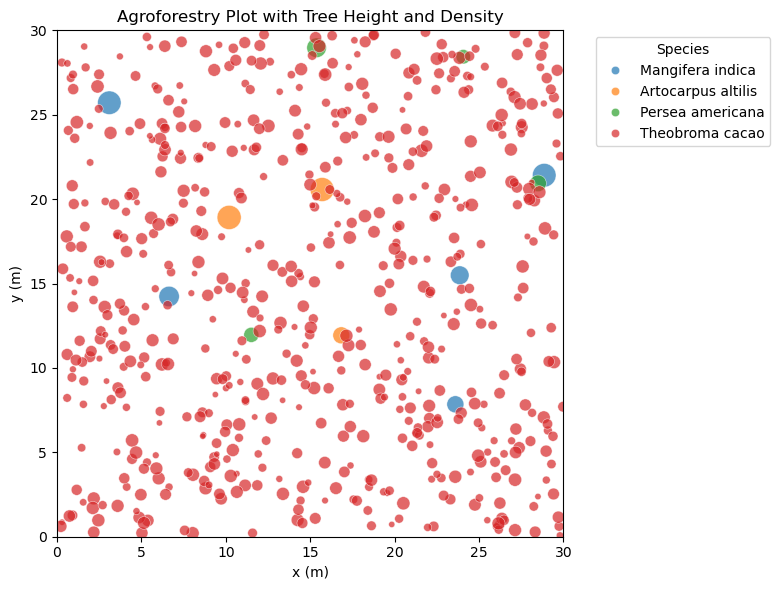

/var/folders/f5/lms0b90j1kx7kk4v552qkjqw0000gp/T/ipykernel_66636/2881159746.py:36: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=one_plot, x="species", y="shade_value", estimator=sum, ci=None)


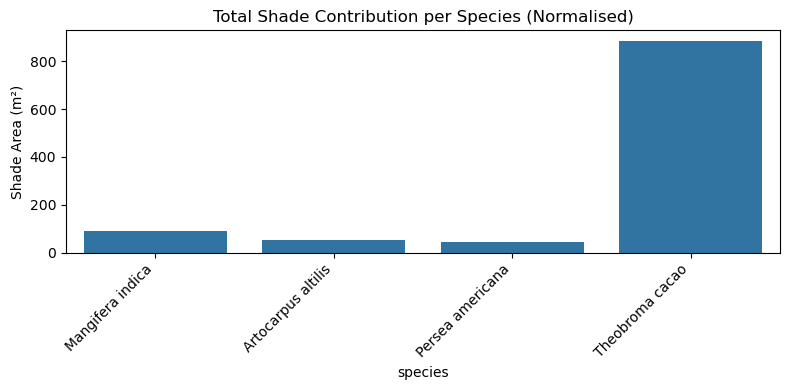

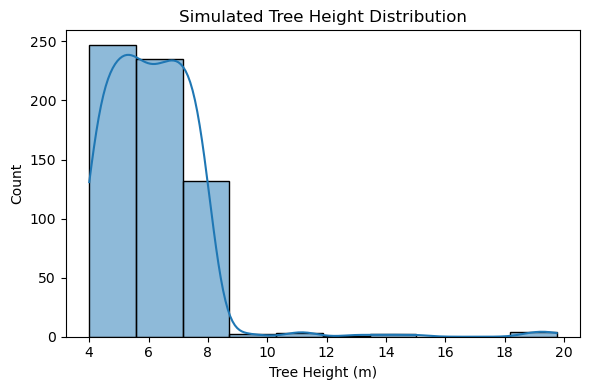

Total simulated shading (from layout): 900.00 m²
Total expected shading (from forest cover): 1071.99 m²


In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random
from scipy.ndimage import gaussian_filter

# --- Select one agroforestry plot (e.g. first) ---
one_plot = simulated_agroforest.copy()
one_plot = normalize_shade_to_forest_cover(one_plot)

# --- Simulate tree layout and cacao layout ---
shade_df = simulate_tree_layout_with_height(one_plot)
cacao_df = simulate_cacao_layout_with_height(int(one_plot.iloc[0].cacao_trees))
combined_df = pd.concat([shade_df, cacao_df])

# --- Generate canopy cover map ---
resolution = 0.25
canopy_cover_map = generate_canopy_cover_map(combined_df, resolution=resolution)

# --- 🔧 Rescale to match expected shade area ---
simulated_total = np.sum(canopy_cover_map) * resolution**2
expected_total = one_plot["shade_value"].sum()
scaling_factor = expected_total / simulated_total if simulated_total > 0 else 1
canopy_cover_map *= scaling_factor
canopy_cover_map = np.clip(canopy_cover_map, 0, 1)  # cap at 100%

# --- Plot canopy cover heatmap ---
plot_canopy_cover_map(canopy_cover_map)

# --- Plot agroforest layout with tree heights ---
plot_agroforest_with_height_from_df(shade_df, cacao_df)

# --- Plot total shade value per species ---
plt.figure(figsize=(8, 4))
sns.barplot(data=one_plot, x="species", y="shade_value", estimator=sum, ci=None)
plt.title("Total Shade Contribution per Species (Normalised)")
plt.ylabel("Shade Area (m²)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# --- Plot tree height distribution ---
plt.figure(figsize=(6, 4))
sns.histplot(combined_df["height"], bins=10, kde=True)
plt.title("Simulated Tree Height Distribution")
plt.xlabel("Tree Height (m)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# --- Compare simulated vs expected shade (after scaling) ---
simulated_total = np.sum(canopy_cover_map) * resolution**2
print(f"Total simulated shading (from layout): {simulated_total:.2f} m²")
print(f"Total expected shading (from forest cover): {expected_total:.2f} m²")


In [14]:
simulated_agroforest

,species,n_trees,role,cacao_trees,plot_size_m2,cacao_density_per_ha,forest_cover,canopy_height,land_use_class,system_type,source,geometry
0,Mangifera indica,5,shade,307,2493,1234,43.0,17.0,Tree cover,Agroforestry,user,POINT (-69.58716 18.81537)
1,Artocarpus altilis,3,food + market,307,2493,1234,43.0,17.0,Tree cover,Agroforestry,user,POINT (-69.58716 18.81537)
2,Persea americana,4,shade + market,307,2493,1234,43.0,17.0,Tree cover,Agroforestry,user,POINT (-69.58716 18.81537)


In [15]:
# 4. model return period for each tree which is outside it's needs

In [16]:
simulated = []

for i, (_, row) in enumerate(gdf.iterrows()):
    gdf_plot = simulate_agroforestry_plot(row)

    if isinstance(gdf_plot, gpd.GeoDataFrame):
        # Diagnose CRS issue
        if gdf_plot.crs is None:
            print(f"CRS missing in plot {i} — setting to EPSG:4326")
            gdf_plot.set_crs("EPSG:4326", inplace=True)
        elif gdf_plot.crs.to_string() != "EPSG:4326":
            print(f"CRS mismatch in plot {i} — converting to EPSG:4326")
            gdf_plot = gdf_plot.to_crs("EPSG:4326")

        # Normalise shading
        gdf_plot = normalize_shade_to_forest_cover(gdf_plot)

        # Ensure CRS is definitely correct after all processing
        gdf_plot.set_crs("EPSG:4326", allow_override=True, inplace=True)
        simulated.append(gdf_plot)

# Final combination
full_agroforestry_df = gpd.GeoDataFrame(pd.concat(simulated, ignore_index=True))
full_agroforestry_df.set_crs("EPSG:4326", allow_override=True, inplace=True)
full_agroforestry_df = full_agroforestry_df[full_agroforestry_df.species!="Theobroma cacao"]


In [17]:
full_agroforestry_df

,species,n_trees,role,cacao_trees,plot_size_m2,cacao_density_per_ha,forest_cover,canopy_height,land_use_class,system_type,source,geometry,raw_shade_area,shade_value
0,Citrus sinensis,8,shade + food,253,2301,1102,88.0,17.0,Tree cover,Agroforestry,simulated,POINT (-70.62000 18.98000),144.764589,53.151543
1,Musa sp.,2,shade + food,253,2301,1102,88.0,17.0,Tree cover,Agroforestry,simulated,POINT (-70.62000 18.98000),20.357520,7.474436
2,Persea americana,4,shade + market,253,2301,1102,88.0,17.0,Tree cover,Agroforestry,simulated,POINT (-70.62000 18.98000),265.904402,97.629049
3,Clusia rosea,1,shade,253,2301,1102,88.0,17.0,Tree cover,Agroforestry,simulated,POINT (-70.62000 18.98000),78.539816,28.836558
4,Hura crepitans,1,large shade,253,2301,1102,88.0,17.0,Tree cover,Agroforestry,simulated,POINT (-70.62000 18.98000),314.159265,115.346230
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
464,Artocarpus altilis,1,food + market,278,2260,1234,96.0,17.0,Tree cover,Agroforestry,simulated,POINT (-70.00695 18.45498),113.097336,38.908062
465,Musa sp.,8,shade + food,278,2260,1234,96.0,17.0,Tree cover,Agroforestry,simulated,POINT (-70.00695 18.45498),81.430082,28.013805
466,Citrus sinensis,1,shade + food,278,2260,1234,96.0,17.0,Tree cover,Agroforestry,simulated,POINT (-70.00695 18.45498),18.095574,6.225290
467,Persea americana,3,shade + market,278,2260,1234,96.0,17.0,Tree cover,Agroforestry,simulated,POINT (-70.00695 18.45498),199.428302,68.607883


In [18]:
import pandas as pd

# Load EcoCrop database
ecocrop = pd.read_csv("/Users/szelie/data/unu/EcoCrop_DB.csv", encoding="latin1")

# Clean species names
ecocrop["ScientificName"] = ecocrop["ScientificName"].str.strip().str.lower()

# Clean your agroforestry species list
agro_species = full_agroforestry_df["species"].dropna().unique()
agro_species_lower = [s.lower() for s in agro_species]

# Filter EcoCrop for your species
climate_cols = ["ScientificName", "TMIN", "TOPMN", "TOPMX", "TMAX", "RMIN", "ROPMN", "ROPMX", "RMAX"]
ecocrop_subset = ecocrop[ecocrop["ScientificName"].isin(agro_species_lower)][climate_cols]

# Rename for clarity
ecocrop_subset.rename(columns={"ScientificName": "species"}, inplace=True)

# Merge with agroforestry data
# Standardise casing and whitespace
full_agroforestry_df["species_clean"] = full_agroforestry_df["species"].str.strip().str.lower()
ecocrop["species_clean"] = ecocrop["ScientificName"].str.strip().str.lower()

# Merge on cleaned names
species_climate_data = full_agroforestry_df.merge(
    ecocrop[["species_clean", "TMIN", "TOPMN", "TOPMX", "TMAX", "RMIN", "ROPMN", "ROPMX", "RMAX"]],
    left_on="species_clean",
    right_on="species_clean",
    how="left"
)


In [19]:
species_climate_data

,species,n_trees,role,cacao_trees,plot_size_m2,cacao_density_per_ha,forest_cover,canopy_height,land_use_class,system_type,...,shade_value,species_clean,TMIN,TOPMN,TOPMX,TMAX,RMIN,ROPMN,ROPMX,RMAX
0,Citrus sinensis,8,shade + food,253,2301,1102,88.0,17.0,Tree cover,Agroforestry,...,53.151543,citrus sinensis,13.0,20.0,30.0,38.0,450.0,1200.0,2000.0,2700.0
1,Musa sp.,2,shade + food,253,2301,1102,88.0,17.0,Tree cover,Agroforestry,...,7.474436,musa sp.,13.0,22.0,32.0,38.0,2000.0,2400.0,2700.0,3500.0
2,Persea americana,4,shade + market,253,2301,1102,88.0,17.0,Tree cover,Agroforestry,...,97.629049,persea americana,10.0,14.0,40.0,45.0,300.0,500.0,2000.0,2500.0
3,Clusia rosea,1,shade,253,2301,1102,88.0,17.0,Tree cover,Agroforestry,...,28.836558,clusia rosea,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Hura crepitans,1,large shade,253,2301,1102,88.0,17.0,Tree cover,Agroforestry,...,115.346230,hura crepitans,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
371,Artocarpus altilis,1,food + market,278,2260,1234,96.0,17.0,Tree cover,Agroforestry,...,38.908062,artocarpus altilis,16.0,21.0,33.0,40.0,1000.0,1500.0,3000.0,3500.0
372,Musa sp.,8,shade + food,278,2260,1234,96.0,17.0,Tree cover,Agroforestry,...,28.013805,musa sp.,13.0,22.0,32.0,38.0,2000.0,2400.0,2700.0,3500.0
373,Citrus sinensis,1,shade + food,278,2260,1234,96.0,17.0,Tree cover,Agroforestry,...,6.225290,citrus sinensis,13.0,20.0,30.0,38.0,450.0,1200.0,2000.0,2700.0
374,Persea americana,3,shade + market,278,2260,1234,96.0,17.0,Tree cover,Agroforestry,...,68.607883,persea americana,10.0,14.0,40.0,45.0,300.0,500.0,2000.0,2500.0


In [20]:
import xarray as xr
import numpy as np
from climada.hazard import Hazard, Centroids
from climada.util.constants import DEF_CRS
from scipy import sparse
import glob
import os

# Define your paths
path = "/Users/szelie/data/unu/terra_climate/"
tmin_files = sorted(glob.glob(os.path.join(path, "TerraClimate_tmin_*.nc")))
tmax_files = sorted(glob.glob(os.path.join(path, "TerraClimate_tmax_*.nc")))

# Load and merge all years
tmin_all = xr.concat(
    [xr.open_dataset(f)["tmin"].sel(lat=slice(20.1, 17), lon=slice(-72.5, -68))
 for f in tmin_files],
    dim="time"
)

tmax_all = xr.concat(
    [xr.open_dataset(f)["tmax"].sel(lat=slice(20.1, 17), lon=slice(-72.5, -68))
 for f in tmax_files],
    dim="time"
)

# Compute mean temperature
tmean = (tmin_all + tmax_all) / 2  # shape: [time, lat, lon]
tmean = tmean.fillna(0)

# Select growing season months
# growing_months = [3, 4, 5, 6, 7, 8, 9, 10]
# tmean_grow = tmean.sel(time=tmean['time.month'].isin(growing_months))

# Aggregate by year
tmean_annual = tmean.groupby('time.year').mean(dim='time')  # shape: [year, lat, lon]

# Prepare for CLIMADA Hazard object
years = tmean_annual.year.values
n_events = len(years)
n_lats = tmean_annual.lat.size
n_lons = tmean_annual.lon.size
n_cells = n_lats * n_lons

# Stack to 2D array: shape [n_events, n_cells]
intensity_data = np.vstack([tmean_annual.sel(year=yr).values.reshape(1, -1) for yr in years])
intensity = sparse.csr_matrix(intensity_data)

# Fraction (all 1s where data exists)
fraction = intensity.copy()
fraction.data.fill(1)

# Build centroids
lon_vals = tmean_annual.lon.values
lat_vals = tmean_annual.lat.values
lon_grid, lat_grid = np.meshgrid(lon_vals, lat_vals)
centroids = Centroids(
    lat=lat_grid.ravel(),
    lon=lon_grid.ravel(),
    crs=DEF_CRS
)

# Create Hazard object
haz = Hazard(
    haz_type="TM",  # e.g. mean Temperature
    intensity=intensity,
    fraction=fraction,
    centroids=centroids,
    units="degC",
    event_id=years,
    event_name=[str(y) for y in years],
    date=np.array([np.datetime64(f"{y}-07-01").astype("datetime64[D]").astype(int) for y in years]),
    orig=np.zeros(n_events, dtype=bool),
    frequency=np.ones(n_events) / n_events
)


In [21]:
tmax_all

<xarray.DataArray 'tmax' (time: 132, lat: 72, lon: 0)> Size: 0B
array([], shape=(132, 72, 0), dtype=float64)
Coordinates:
  * lat      (lat) float64 576B 19.98 19.94 19.9 19.85 ... 17.1 17.06 17.02
  * time     (time) datetime64[ns] 1kB 1995-01-01 1995-02-01 ... 2005-12-01
  * lon      (lon) float64 0B 
Attributes:
    units:              degC
    description:        Maximum 2-m Temperature
    long_name:          air_temperature
    standard_name:      air_temperature
    dimensions:         lon lat time
    grid_mapping:       crs
    coordinate_system:  WGS84,EPSG:4326
    _ChunkSizes:        [   1  720 1440]

In [22]:
import pandas as pd
import numpy as np
from climada.entity import ImpactFunc, ImpactFuncSet

def make_step_impact_func(hazard_type, species, min_thresh, max_thresh, counter):
    impf = ImpactFunc()
    impf.haz_type = hazard_type
    impf.id = counter
    impf.name = f"{species}_{hazard_type}"
    impf.unit = '°C' if hazard_type == "TM" else 'mm'

    impf.intensity = (
        np.array([0, min_thresh, min_thresh, max_thresh, max_thresh, 60])
        if hazard_type == "TM"
        else np.array([0, min_thresh, min_thresh, max_thresh, max_thresh, 6000])
    )
    impf.mdd = np.array([1, 1, 0, 0, 1, 1])
    impf.paa = np.ones_like(impf.intensity)
    impf.check()
    return impf

# Initialize
impf_set = ImpactFuncSet()
species_to_temp_id = {}
species_to_prec_id = {}
counter = 1

# Default placeholder thresholds
DEFAULT_TEMP = (10, 40)   # in °C
DEFAULT_PREC = (500, 3000)  # in mm

for species in species_climate_data["species"].unique():
    row = species_climate_data[species_climate_data["species"] == species].iloc[0]

    # Use real or default thresholds
    tmin = row["TMIN"] if pd.notnull(row["TMIN"]) else DEFAULT_TEMP[0]
    tmax = row["TMAX"] if pd.notnull(row["TMAX"]) else DEFAULT_TEMP[1]
    rmin = row["RMIN"] if pd.notnull(row["RMIN"]) else DEFAULT_PREC[0]
    rmax = row["RMAX"] if pd.notnull(row["RMAX"]) else DEFAULT_PREC[1]

    # TEMP
    impf_temp = make_step_impact_func("TM", species, tmin, tmax, counter)
    impf_set.append(impf_temp)
    species_to_temp_id[species] = counter
    counter += 1

    # PREC
    impf_prec = make_step_impact_func("PR", species, rmin, rmax, counter)
    impf_set.append(impf_prec)
    species_to_prec_id[species] = counter
    counter += 1

# Assign IDs
full_agroforestry_df["impf_TM"] = full_agroforestry_df["species"].map(species_to_temp_id)
full_agroforestry_df["impf_PR"] = full_agroforestry_df["species"].map(species_to_prec_id)


In [23]:
full_agroforestry_df

,species,n_trees,role,cacao_trees,plot_size_m2,cacao_density_per_ha,forest_cover,canopy_height,land_use_class,system_type,source,geometry,raw_shade_area,shade_value,species_clean,impf_TM,impf_PR
0,Citrus sinensis,8,shade + food,253,2301,1102,88.0,17.0,Tree cover,Agroforestry,simulated,POINT (-70.62000 18.98000),144.764589,53.151543,citrus sinensis,1,2
1,Musa sp.,2,shade + food,253,2301,1102,88.0,17.0,Tree cover,Agroforestry,simulated,POINT (-70.62000 18.98000),20.357520,7.474436,musa sp.,3,4
2,Persea americana,4,shade + market,253,2301,1102,88.0,17.0,Tree cover,Agroforestry,simulated,POINT (-70.62000 18.98000),265.904402,97.629049,persea americana,5,6
3,Clusia rosea,1,shade,253,2301,1102,88.0,17.0,Tree cover,Agroforestry,simulated,POINT (-70.62000 18.98000),78.539816,28.836558,clusia rosea,7,8
4,Hura crepitans,1,large shade,253,2301,1102,88.0,17.0,Tree cover,Agroforestry,simulated,POINT (-70.62000 18.98000),314.159265,115.346230,hura crepitans,9,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
464,Artocarpus altilis,1,food + market,278,2260,1234,96.0,17.0,Tree cover,Agroforestry,simulated,POINT (-70.00695 18.45498),113.097336,38.908062,artocarpus altilis,11,12
465,Musa sp.,8,shade + food,278,2260,1234,96.0,17.0,Tree cover,Agroforestry,simulated,POINT (-70.00695 18.45498),81.430082,28.013805,musa sp.,3,4
466,Citrus sinensis,1,shade + food,278,2260,1234,96.0,17.0,Tree cover,Agroforestry,simulated,POINT (-70.00695 18.45498),18.095574,6.225290,citrus sinensis,1,2
467,Persea americana,3,shade + market,278,2260,1234,96.0,17.0,Tree cover,Agroforestry,simulated,POINT (-70.00695 18.45498),199.428302,68.607883,persea americana,5,6


In [24]:
# to do: improve shading definition, calculated impact present and future, improve shading definition

In [25]:
# Compute impact
from climada.engine import ImpactCalc
from climada.entity import Exposures

full_agroforestry_df['value'] = full_agroforestry_df.shade_value
exp= Exposures(data=full_agroforestry_df)
impact = ImpactCalc(exp, impf_set, haz).impact(
    save_mat=True
)  # Do not save the results geographically resolved (only aggregate values)


2025-06-03 11:06:17,487 - climada.engine.impact_calc - WARNING - No exposures with value >0 in the vicinity of the hazard.


In [26]:
impact.eai_exp

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0.

<GeoAxes: title={'center': 'Expected annual impact'}>

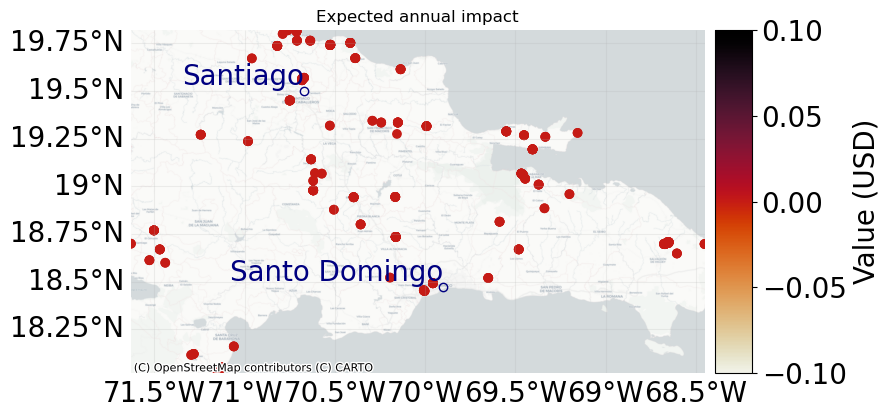

In [27]:
impact.plot_basemap_eai_exposure()

In [28]:
full_agroforestry_df['eai_exp'] = impact.eai_exp

In [29]:
full_agroforestry_df[full_agroforestry_df.eai_exp>0]

,species,n_trees,role,cacao_trees,plot_size_m2,cacao_density_per_ha,forest_cover,canopy_height,land_use_class,system_type,source,geometry,raw_shade_area,shade_value,species_clean,impf_TM,impf_PR,value,eai_exp


In [33]:
import os
import glob
import xarray as xr
import numpy as np
from climada.hazard import Hazard, Centroids
from climada.util.constants import DEF_CRS
from scipy import sparse

# Base folders
paths = {
    "historical": "/Users/szelie/data/unu/terra_climate/",
    "plus2C": "/Users/szelie/data/unu/terra_climate_scenarios_ncss/",
    "plus4C": "/Users/szelie/data/unu/terra_climate_scenarios_ncss/"
}

def get_annual_means(path, varname):
    files = sorted(glob.glob(os.path.join(path, f"TerraClimate*_{varname}_*_CA.nc")))
    data = xr.concat([xr.open_dataset(f)[varname] for f in files], dim="time")
    return data.groupby("time.year").mean(dim="time")

def create_hazard_from_array(dataarray, haz_type, units):
    years = dataarray.year.values
    n_events = len(years)
    lat_vals = dataarray.lat.values
    lon_vals = dataarray.lon.values
    lon_grid, lat_grid = np.meshgrid(lon_vals, lat_vals)
    n_cells = lat_grid.size

    # Flatten to [n_events, n_cells]
    intensity_data = np.vstack([dataarray.sel(year=yr).values.reshape(1, -1) for yr in years])
    intensity = sparse.csr_matrix(intensity_data)

    # All valid cells get full fraction
    fraction = intensity.copy()
    fraction.data.fill(1)

    centroids = Centroids(
        lat=lat_grid.ravel(),
        lon=lon_grid.ravel(),
        crs=DEF_CRS
    )

    return Hazard(
        haz_type=haz_type,
        intensity=intensity,
        fraction=fraction,
        centroids=centroids,
        units=units,
        event_id=years,
        event_name=[str(y) for y in years],
        date=np.array([np.datetime64(f"{y}-07-01").astype("datetime64[D]").astype(int) for y in years]),
        orig=np.zeros(n_events, dtype=bool),
        frequency=np.ones(n_events) / n_events
    )

# Final dict
hazard_dict = {}

for scenario, path in paths.items():
    print(f"Processing {scenario}...")
    tmin = get_annual_means(path, "tmin")
    tmax = get_annual_means(path, "tmax")
    ppt = get_annual_means(path, "ppt")
    tmean = (tmin + tmax) / 2

    haz_tmean = create_hazard_from_array(tmean, haz_type="TM", units="degC")
    haz_ppt = create_hazard_from_array(ppt, haz_type="PR", units="mm")

    hazard_dict[scenario] = {
        "TM": haz_tmean,
        "PR": haz_ppt
    }


Processing historical...
Processing plus2C...
Processing plus4C...


In [34]:
# Compute impact
from climada.engine import ImpactCalc
from climada.entity import Exposures


impact = {scenario:{haz:ImpactCalc(exp, impf_set, hazard_dict[scenario][haz]).impact(
    save_mat=True
) for haz in hazard_dict[scenario]} for scenario in hazard_dict}  # Do not save the results geographically resolved (only aggregate values)


2025-06-03 11:28:41,264 - climada.util.coordinates - WARNING - Distance to closest centroid is greater than 100km for 84 coordinates.
2025-06-03 11:28:41,266 - climada.engine.impact_calc - WARNING - No exposures with value >0 in the vicinity of the hazard.
2025-06-03 11:28:41,395 - climada.util.coordinates - WARNING - Distance to closest centroid is greater than 100km for 84 coordinates.
2025-06-03 11:28:41,396 - climada.engine.impact_calc - WARNING - No exposures with value >0 in the vicinity of the hazard.
2025-06-03 11:28:41,521 - climada.util.coordinates - WARNING - Distance to closest centroid is greater than 100km for 84 coordinates.
2025-06-03 11:28:41,522 - climada.engine.impact_calc - WARNING - No exposures with value >0 in the vicinity of the hazard.
2025-06-03 11:28:41,656 - climada.util.coordinates - WARNING - Distance to closest centroid is greater than 100km for 84 coordinates.
2025-06-03 11:28:41,658 - climada.engine.impact_calc - WARNING - No exposures with value >0 in 

In [35]:
impact['historical']['TM'].imp_mat

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 0 stored elements and shape (21, 376)>

In [36]:
import xarray as xr

ds = xr.open_dataset("/Users/szelie/data/unu/terra_climate/TerraClimate_tmin_2000_CA.nc")
print(ds)
print(ds['tmin'].values.shape)
print(np.nanmin(ds['tmin'].values), np.nanmax(ds['tmin'].values))


<xarray.Dataset> Size: 17MB
Dimensions:  (crs: 1, lat: 360, time: 12, lon: 480)
Coordinates:
  * crs      (crs) int16 2B 3
  * lat      (lat) float64 3kB 19.98 19.94 19.9 19.85 ... 5.104 5.063 5.021
  * time     (time) datetime64[ns] 96B 2000-01-01 2000-02-01 ... 2000-12-01
  * lon      (lon) float64 4kB -94.98 -94.94 -94.9 ... -75.1 -75.06 -75.02
Data variables:
    tmin     (time, lat, lon) float64 17MB ...
Attributes: (12/49)
    method:                          These layers from TerraClimate were crea...
    title:                           TerraClimate: monthly climate and climat...
    summary:                         This archive contains a dataset of high-...
    keywords:                        WORLDCLIM,global,monthly, temperature,pr...
    id:                              Blank
    naming_authority:                edu.uidaho.nkn
    ...                              ...
    geospatial_vertical_resolution:  0.0
    geospatial_vertical_positive:    Up
    references:           